# SVM Kernel Tutorial

In [1]:
# 1 – Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

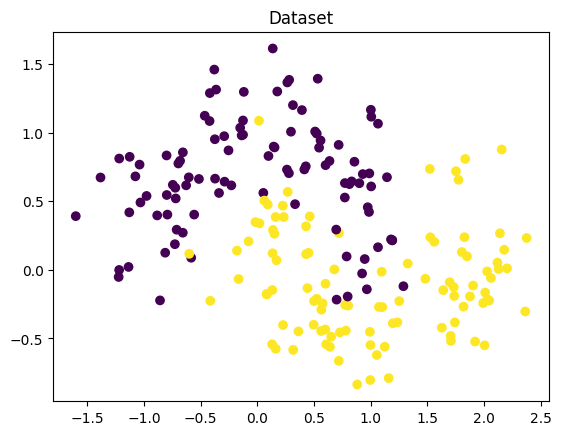

In [8]:
# 2 – Generate non-linear dataset
X, y = datasets.make_moons(n_samples=200, noise=0.25, random_state=42)

# Plot dataset
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Dataset")
plt.show()

In [9]:
# 3 – Define function to plot decision boundary
def plot_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(title)
    plt.show()

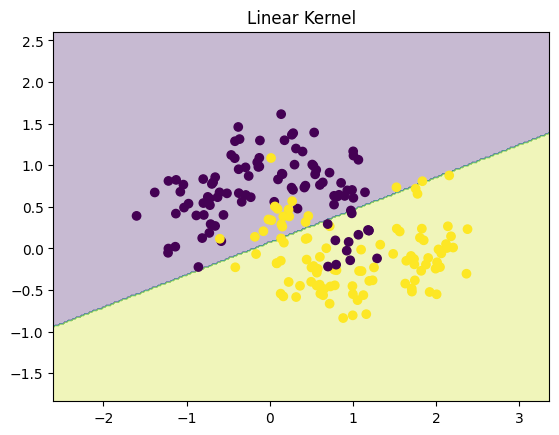

In [10]:
# 4 – Train linear SVM
linear = SVC(kernel='linear')
linear.fit(X, y)
plot_boundary(linear, X, y, "Linear Kernel")

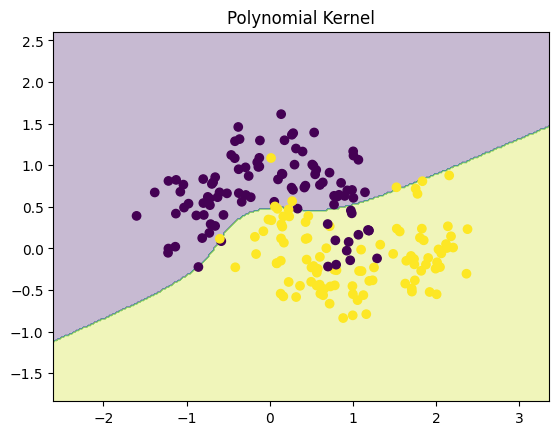

In [11]:
# 5 – Train polynomial SVM
poly = SVC(kernel='poly', degree=3)
poly.fit(X, y)
plot_boundary(poly, X, y, "Polynomial Kernel")

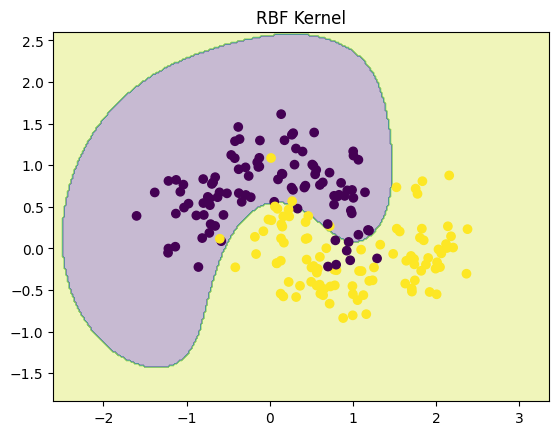

In [12]:
# 6 – Train RBF SVM
rbf = SVC(kernel='rbf', gamma=1)
rbf.fit(X, y)
plot_boundary(rbf, X, y, "RBF Kernel")

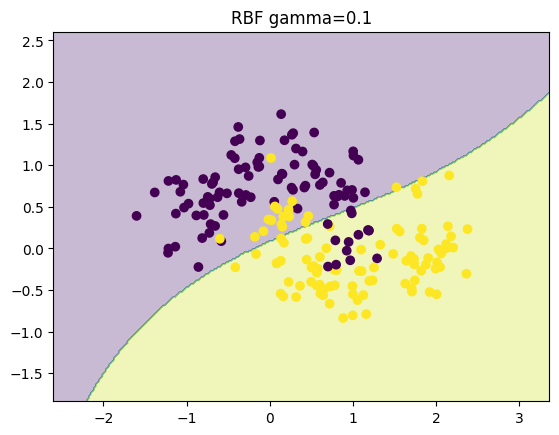

In [13]:
# 7 – Show effect of gamma (underfitting)
low_gamma = SVC(kernel='rbf', gamma=0.1)
low_gamma.fit(X, y)
plot_boundary(low_gamma, X, y, "RBF gamma=0.1")

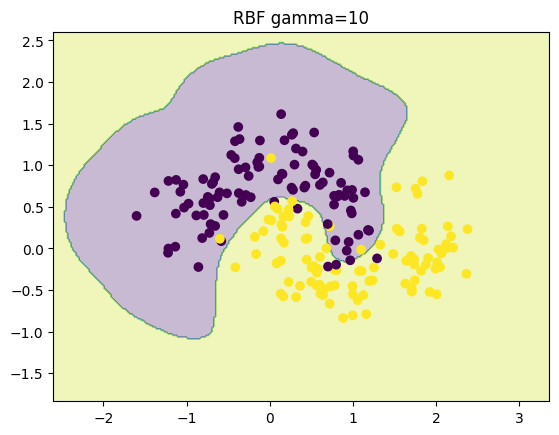

In [14]:
# 8 – Show effect of gamma (overfitting)
high_gamma = SVC(kernel='rbf', gamma=10)
high_gamma.fit(X, y)
plot_boundary(high_gamma, X, y, "RBF gamma=10")